In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def show(images, titles, cmap_list=None, figsize=(16, 4)):
    """Helper: display multiple images side by side."""
    n = len(images)
    if cmap_list is None:
        cmap_list = ['gray'] * n

    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]

    for ax, img, title, cmap in zip(axes, images, titles, cmap_list):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.show()


img_gray = cv2.imread('image.jpg', cv2.IMREAD_GRAYSCALE)
if img_gray is None:
    x = np.linspace(0, 255, 512, dtype=np.uint8)
    img_gray = np.tile(x, (512, 1))
    cv2.circle(img_gray, (160, 160), 90, 30, -1)
    cv2.rectangle(img_gray, (320, 80), (460, 220), 220, -1)
    cv2.putText(img_gray, 'IPPR', (125, 420), cv2.FONT_HERSHEY_SIMPLEX, 2, 180, 4, cv2.LINE_AA)

print('Setup complete. Image shape:', img_gray.shape)

Setup complete. Image shape: (350, 625)


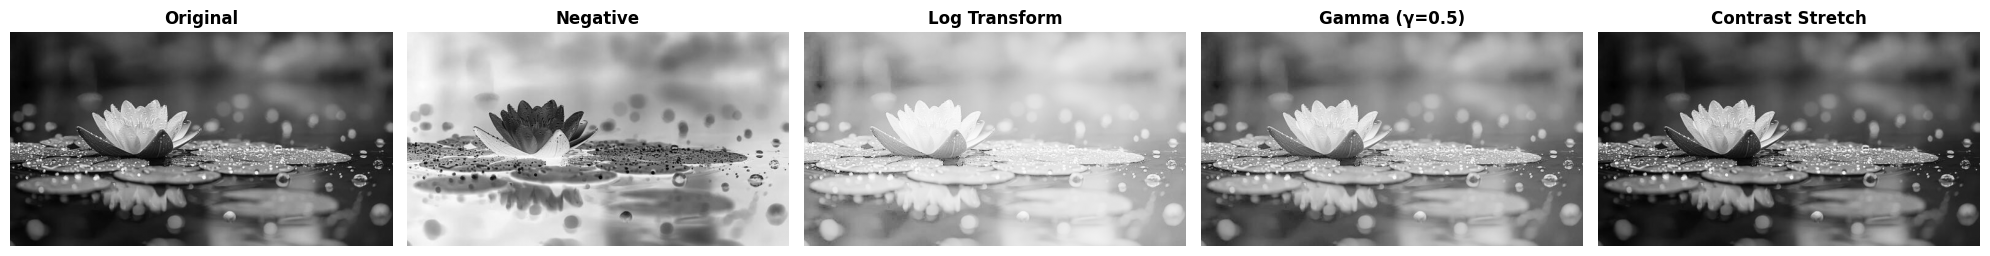

Intensity Transformations complete.


In [10]:
def intensity_transformations(img):
    img = img.astype(np.float64)
    L = 256

    # 1. Image Negative
    negative = L - 1 - img

    # 2. Log Transformation: s = c * log(1 + r)
    c = (L - 1) / np.log(1 + np.max(img))
    log_img = c * np.log(1 + img)

    # 3. Power-Law (Gamma) Transformation
    gamma = 0.5
    gamma_img = np.power(img / 255.0, gamma) * 255

    # 4. Contrast Stretching
    r_min, r_max = img.min(), img.max()
    if r_max > r_min:
        contrast = (img - r_min) / (r_max - r_min) * 255
    else:
        contrast = np.zeros_like(img)

    images = [
        img.astype(np.uint8),
        negative.astype(np.uint8),
        log_img.astype(np.uint8),
        gamma_img.astype(np.uint8),
        contrast.astype(np.uint8)
    ]
    titles = ['Original', 'Negative', 'Log Transform', f'Gamma (γ={gamma})', 'Contrast Stretch']
    show(images, titles, figsize=(20, 4))
    print('Intensity Transformations complete.')


intensity_transformations(img_gray)

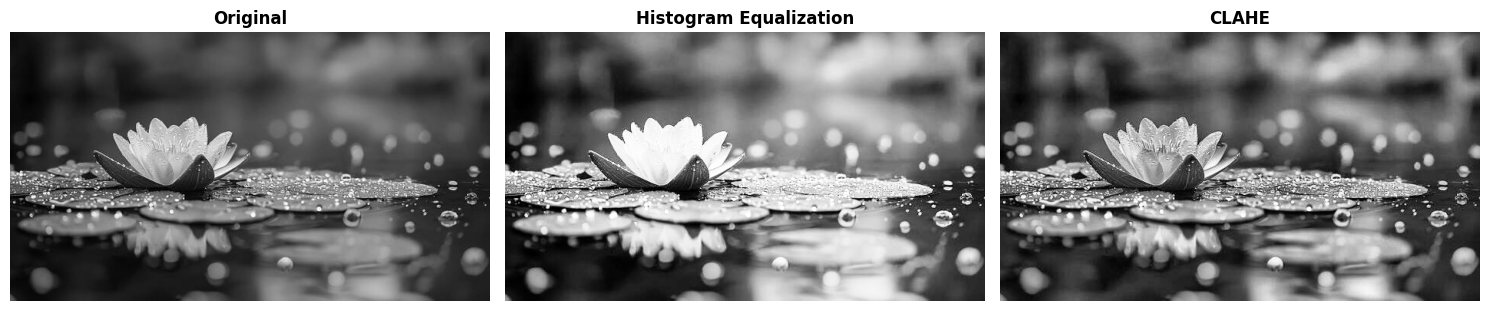

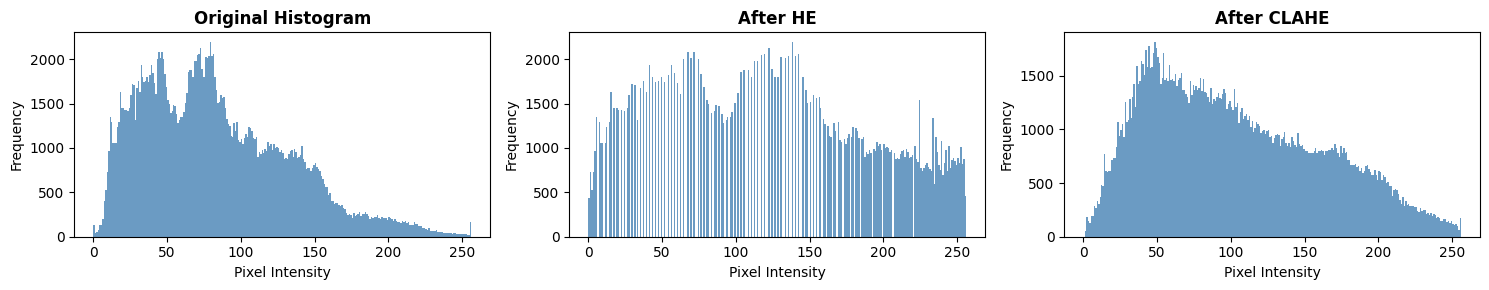

Histogram Processing complete.


In [11]:
def histogram_processing(img):
    # Standard Histogram Equalization
    hist_eq = cv2.equalizeHist(img)

    # CLAHE (Contrast Limited Adaptive Histogram Equalization)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img = clahe.apply(img)

    # Plot images
    show(
        [img, hist_eq, clahe_img],
        ['Original', 'Histogram Equalization', 'CLAHE'],
        figsize=(15, 4)
    )

    # Plot histograms
    fig, axes = plt.subplots(1, 3, figsize=(15, 3))
    for ax, image, title in zip(
        axes,
        [img, hist_eq, clahe_img],
        ['Original Histogram', 'After HE', 'After CLAHE']
    ):
        ax.hist(image.ravel(), bins=256, range=(0, 256), color='steelblue', alpha=0.8)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Pixel Intensity')
        ax.set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()
    print('Histogram Processing complete.')


histogram_processing(img_gray)

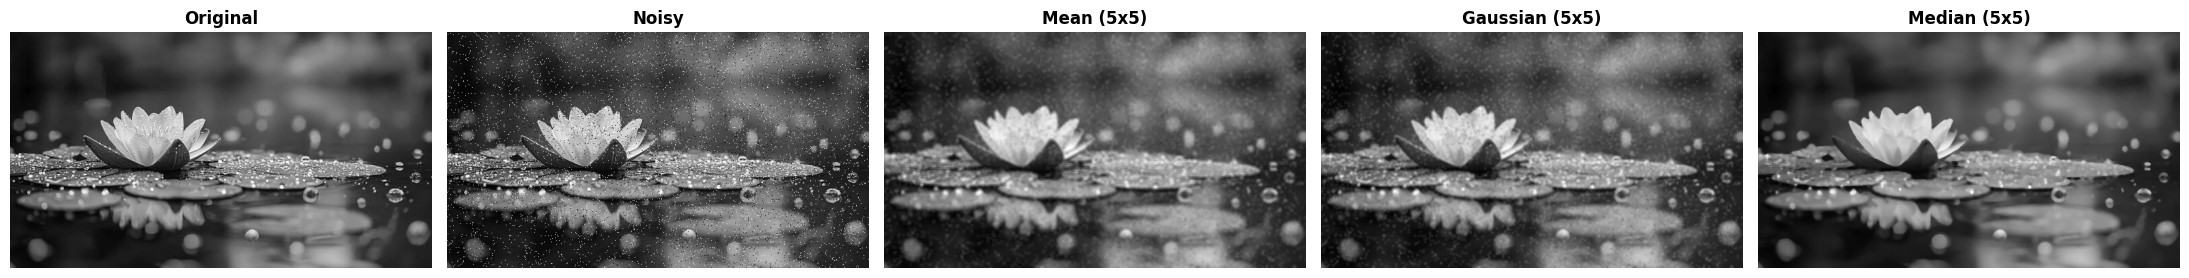

Smoothing Filters complete.


In [12]:
def smoothing_filters(img):
    # Add salt-and-pepper noise for demonstration
    noisy = img.copy()
    num_salt = int(0.02 * img.size)

    coords = (np.random.randint(0, img.shape[0], num_salt), np.random.randint(0, img.shape[1], num_salt))
    noisy[coords] = 255

    coords = (np.random.randint(0, img.shape[0], num_salt), np.random.randint(0, img.shape[1], num_salt))
    noisy[coords] = 0

    ksize = 5

    # 1. Mean (Averaging) Filter
    mean_f = cv2.blur(noisy, (ksize, ksize))

    # 2. Gaussian Filter
    gauss_f = cv2.GaussianBlur(noisy, (ksize, ksize), sigmaX=1.5)

    # 3. Median Filter (best for salt-and-pepper)
    median_f = cv2.medianBlur(noisy, ksize)

    show(
        [img, noisy, mean_f, gauss_f, median_f],
        ['Original', 'Noisy', f'Mean ({ksize}x{ksize})', f'Gaussian ({ksize}x{ksize})', f'Median ({ksize}x{ksize})'],
        figsize=(22, 4)
    )
    print('Smoothing Filters complete.')


smoothing_filters(img_gray)

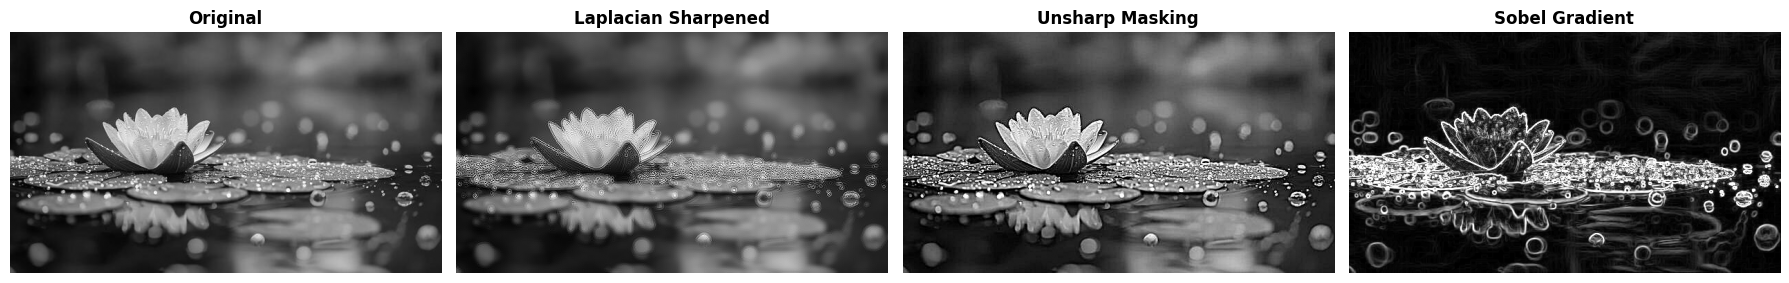

Sharpening Filters complete.


In [13]:
def sharpening_filters(img):
    img_f = img.astype(np.float64)

    # 1. Laplacian Sharpening
    laplacian_kernel = np.array([[0, -1, 0],
                                 [-1, 4, -1],
                                 [0, -1, 0]], dtype=np.float64)
    laplacian = cv2.filter2D(img_f, -1, laplacian_kernel)
    laplacian_sharp = np.clip(img_f - laplacian, 0, 255).astype(np.uint8)

    # 2. Unsharp Masking
    k = 1.5
    blurred = cv2.GaussianBlur(img, (9, 9), sigmaX=2.0).astype(np.float64)
    unsharp = np.clip(img_f + k * (img_f - blurred), 0, 255).astype(np.uint8)

    # 3. Sobel Gradient
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = np.clip(np.sqrt(sobelx**2 + sobely**2), 0, 255).astype(np.uint8)

    show(
        [img, laplacian_sharp, unsharp, sobel_mag],
        ['Original', 'Laplacian Sharpened', 'Unsharp Masking', 'Sobel Gradient'],
        figsize=(18, 4)
    )
    print('Sharpening Filters complete.')


sharpening_filters(img_gray)

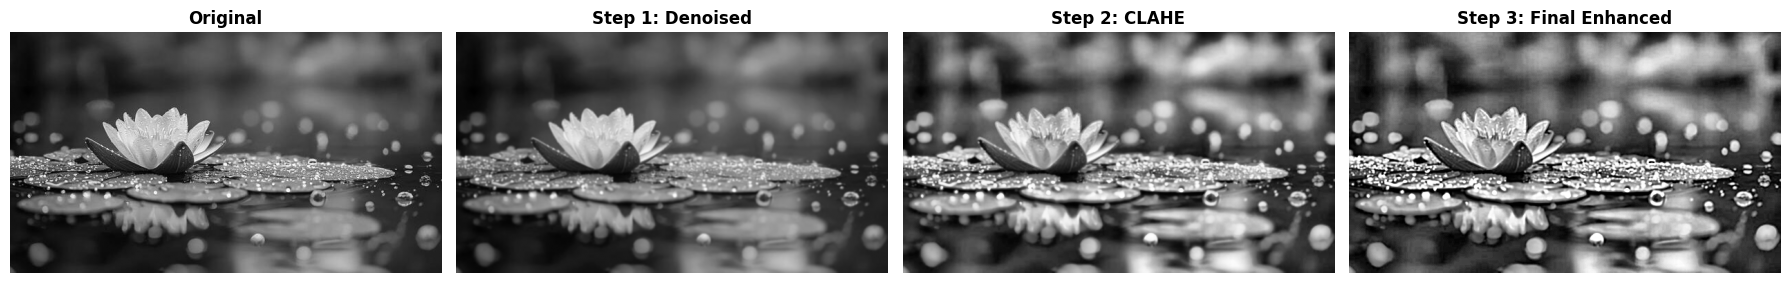

Full Pipeline complete. PSNR (original vs enhanced): 15.79 dB


In [14]:
def full_enhancement_pipeline(img):
    """
    A realistic image enhancement pipeline:
    Step 1: Denoise with Gaussian filter
    Step 2: CLAHE for contrast enhancement
    Step 3: Unsharp masking for sharpness
    """
    denoised = cv2.GaussianBlur(img, (5, 5), sigmaX=1.0)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(denoised)

    blurred = cv2.GaussianBlur(enhanced, (9, 9), sigmaX=2.0).astype(np.float64)
    k = 1.2
    sharpened = np.clip(
        enhanced.astype(np.float64) + k * (enhanced.astype(np.float64) - blurred),
        0,
        255
    ).astype(np.uint8)

    show(
        [img, denoised, enhanced, sharpened],
        ['Original', 'Step 1: Denoised', 'Step 2: CLAHE', 'Step 3: Final Enhanced'],
        figsize=(18, 4)
    )

    psnr = cv2.PSNR(img, sharpened)
    print(f'Full Pipeline complete. PSNR (original vs enhanced): {psnr:.2f} dB')


full_enhancement_pipeline(img_gray)